# xml: html처럼 태그 기반으로 자료를 저장한 포멧
* xml parser를 통해서 str을 xml로 변환하는 작업이 필요
* xml로 변환이 되면 태그 기반으로 자료를 찾아서 정리
* 태크에서 자료를 추출할 때는 beautifulsoup이라는 라이브러리를 이용

# json으로 가져오기

In [1]:
import os
import requests
import pandas as pd
import time

In [4]:
servicekey = "cNx+1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO/U+UhQqKv2E4WScQrT/mI1hrZR4ayBRqtIaKHC3BywjHiX3w=="
url = "http://apis.data.go.kr/B551408/rent-loan-rate-info/rate-list"
payload = dict(servicekey = servicekey, numOfRows = 20, pageNo = 1, dataType = "JSON")
r = requests.get(url, params=payload)
response = r.json()
response

{'header': {'resultCode': '00', 'resultMsg': '정상'},
 'body': {'pageNo': 1,
  'totalCount': 18,
  'numOfRows': 20,
  'items': [{'bssYmdStart': '20250310',
    'interest4_1': '0',
    'interest3_2': '0',
    'interest4_2': '0',
    'interest2_1': '0',
    'interest1_2': '0',
    'interest3_1': '0',
    'interest2_2': '0',
    'interest1_1': '0',
    'bssYmdEnd': '20250316',
    'organId': '산업은행',
    'callCenter': '1588-1500'},
   {'bssYmdStart': '20250310',
    'interest4_1': '0',
    'interest3_2': '0',
    'interest4_2': '0',
    'interest2_1': '0',
    'interest1_2': '0',
    'interest3_1': '0',
    'interest2_2': '0',
    'interest1_1': '0',
    'bssYmdEnd': '20250316',
    'organId': '제주은행',
    'callCenter': '1588-0079'},
   {'bssYmdStart': '20250310',
    'interest4_1': '0',
    'interest3_2': '0',
    'interest4_2': '0',
    'interest2_1': '0',
    'interest1_2': '0',
    'interest3_1': '0',
    'interest2_2': '0',
    'interest1_1': '0',
    'bssYmdEnd': '20250316',
    'organI

In [57]:
len(response['body']['items'])

18

In [53]:
result={}
for item in response['body']['items']:
    for key, value in item.items():
        result.setdefault(key, []).append(value)

df = pd.DataFrame(result)
df

,bssYmdStart,interest4_1,interest3_2,interest4_2,interest2_1,interest1_2,interest3_1,interest2_2,interest1_1,bssYmdEnd,organId,callCenter
0,20250310,0,0,0,0,0,0,0,0,20250316,산업은행,1588-1500
1,20250310,0,0,0,0,0,0,0,0,20250316,제주은행,1588-0079
2,20250310,0,0,0,0,0,0,0,0,20250316,SC은행,1588-1599
3,20250310,4.89,0,0,0,0,0,0,0,20250316,전북은행,1588-4477
4,20250310,0,0,0,0,0,0,0,0,20250316,수협은행,1588-1515
5,20250310,4.26,0,0,0,0,0,0,0,20250316,우리은행,1599-5000
6,20250310,4.64,0,0,0,0,0,0,0,20250316,경남은행,1588-8585
7,20250310,3.5,0,0,0,0,0,0,0,20250316,카카오뱅크,1599-3333
8,20250310,3.38,0,0,0,0,0,0,0,20250316,아이엠뱅크,1588-5050
9,20250310,4.18,0,0,0,0,0,0,0,20250316,하나은행,1599-1111


### 파싱
* 일반 문자열이 아닌, 특정 문서 형식으로 변환하는 것
* 문자열 => xml, 문자열 => html
* **일반 문자열을 DOM tree 구조로 변환한다!**

# xml로 가져오기

In [5]:
servicekey = "cNx+1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO/U+UhQqKv2E4WScQrT/mI1hrZR4ayBRqtIaKHC3BywjHiX3w=="
url = "http://apis.data.go.kr/B551408/rent-loan-rate-info/rate-list"
payload = dict(servicekey = servicekey, numOfRows = 20, pageNo = 1, dataType = "XML")
r = requests.get(url, params=payload)
response = r.text
response

'<response><header><resultCode>00</resultCode><resultMsg>정상</resultMsg></header><body><pageNo>1</pageNo><totalCount>18</totalCount><numOfRows>20</numOfRows><items><item><bssYmdStart>20250310</bssYmdStart><interest4_1>0</interest4_1><interest3_2>0</interest3_2><interest4_2>0</interest4_2><interest2_1>0</interest2_1><interest1_2>0</interest1_2><interest3_1>0</interest3_1><interest2_2>0</interest2_2><interest1_1>0</interest1_1><bssYmdEnd>20250316</bssYmdEnd><organId>산업은행</organId><callCenter>1588-1500</callCenter></item><item><bssYmdStart>20250310</bssYmdStart><interest4_1>0</interest4_1><interest3_2>0</interest3_2><interest4_2>0</interest4_2><interest2_1>0</interest2_1><interest1_2>0</interest1_2><interest3_1>0</interest3_1><interest2_2>0</interest2_2><interest1_1>0</interest1_1><bssYmdEnd>20250316</bssYmdEnd><organId>제주은행</organId><callCenter>1588-0079</callCenter></item><item><bssYmdStart>20250310</bssYmdStart><interest4_1>0</interest4_1><interest3_2>0</interest3_2><interest4_2>0</inte

* xml로 데이터를 받으면 처음에는 단순 문자열로 받게 된다.
* 문자열을 xml 문서로 변환해야 함
* beautifulsoup을 이용해 변환
* beautifulsoup의 메서드인 select, select_

In [ ]:
# !pip install beautifulsoup4

# BeautifulSoup

* https://www.crummy.com/software/BeautifulSoup/bs4/doc/ 참고
* pip install beautifulsoup4
* from bs4 import BeautifulSoup as bs
* find, find_all 함수: xml, html 에서 태그 기반으로 내용을 찾음
* **select, select_one**함수: xml, html에서 css selector 기반으로 내용을 찾음
* find_all, select는 해당 태그나 css selector를 가진 부분을 모두 찾아서 list로 반환
* find, select_one은 여러 태그나 css selector 중에서 가장 먼저 나오는 태그/selector를 한 개만 찾아줌
* 찾아온 태그 .name: 태그 이름 반환
* 찾아온 태그 .text or .string: 태그 안쪽의 텍스트 반환

In [58]:
from bs4 import BeautifulSoup as bs

In [59]:
soup = bs(response, 'xml')
print(soup)

<?xml version="1.0" encoding="utf-8"?>
<response>
<header>
<resultCode>00</resultCode>
<resultMsg>NORMAL SERVICE.</resultMsg>
</header>
<body>
<numOfRows>1000</numOfRows>
<pageNo>5</pageNo>
<totalCount>4741</totalCount>
<items>
<item>
<basYm>202111</basYm>
<snq>465</snq>
<finPrdNm>전라북도 더불어행복론</finPrdNm>
<lnLmt>1500만원</lnLmt>
<irtCtg>고정금리</irtCtg>
<irt>2.0~4.0%</irt>
<maxTotLnTrm>5년</maxTotLnTrm>
<maxDfrmTrm>0년</maxDfrmTrm>
<maxRdptTrm>5년</maxRdptTrm>
<rdptMthd>원리금균등분할상환</rdptMthd>
<usge>운영·시설, 생계, 저금리전환, 학자금</usge>
<trgt>채무조정자</trgt>
<instCtg>일반기관</instCtg>
<ofrInstNm>신용회복위원회</ofrInstNm>
<rsdAreaPamtEqltIstm>전라북도</rsdAreaPamtEqltIstm>
<suprTgtDtlCond>- 개인회생 성실상환자 : 전라북도 거주자로서 법원의 개인회생 인가를 받아 18개월 이상 변제계획을 성실하게 이행하고 있거나 최근 3년 이내 이행을 완료한 자, 최대 700만원 한도&lt;br&gt;- 채무조정 성실상환자 : 전라북도 거주자로서 신용회복지원을 받아 6개월 이상 변제 계획을 성실하게 이행하고 있거나 최근 3년 이내 이행을 완료한 자, 최대 1,500만원 한도</suprTgtDtlCond>
<age>없음</age>
<incm>없음</incm>
<rsdArea xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:nil="true"/>
<crd

In [7]:
soup.select_one("resultCode")

<resultCode>00</resultCode>

In [8]:
items = soup.select_one('items')
items.select_one("bssYmdStart").name

'bssYmdStart'

In [9]:
items = soup.select_one('items')
item = items.select("item")
bssYmdStart_list = items.select("bssYmdStart")

In [10]:
bssYmdStart_list

[<bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>,
 <bssYmdStart>20250310</bssYmdStart>]

In [80]:
for tag in items.select_one("item"):
    print(tag.name)

bssYmdStart
interest4_1
interest3_2
interest4_2
interest2_1
interest1_2
interest3_1
interest2_2
interest1_1
bssYmdEnd
organId
callCenter


In [11]:
items = soup.select_one('items')
bssYmdStart_list = items.select("bssYmdStart")
interest4_1_list = items.select("interest4_1")
interest3_2_list = items.select("interest3_2")
interest4_2_list = items.select("interest4_2")
interest2_1_list = items.select("interest2_1")
interest1_2_list = items.select("interest1_2")
interest3_1_list = items.select("interest3_1")
interest2_2_list = items.select("interest2_2")
interest1_1_list = items.select("interest1_1")
bssYmdStart_list = items.select("bssYmdStart")
organId_list = items.select("organId")
callCenter_list = items.select("callCenter")

In [13]:
tag_list = [bssYmdStart_list, interest4_1_list, interest3_2_list, interest4_2_list, interest2_1_list, interest1_2_list, interest3_1_list, interest2_2_list, interest1_1_list, bssYmdStart_list, organId_list, callCenter_list]

In [14]:
result = {}
for lists in tag_list:
    for item in lists:
        result.setdefault(item.name, []).append(item.text)
result

{'bssYmdStart': ['20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310',
  '20250310'],
 'interest4_1': ['0',
  '0',
  '0',
  '4.89',
  '0',
  '4.26',
  '4.64',
  '3.5',
  '3.38',
  '4.18',
  '3.74',
  '3.7',
  '3.89',
  '3.84',
  '4.05',
  '4.0',
  '4.11',
  '4.07'],
 'interest3_2': ['0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0'],
 'interest4_2': ['0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0',
  '0'],
 'interest2_1':

In [15]:
df = pd.DataFrame(result)
df

ValueError: All arrays must be of the same length

# 반복문으로 태그를 자동 추출해서 만들기

In [120]:
for tag in soup.select("items")[0]:
    for key in tag:
        print(key.name, key.text)

bssYmdStart 20250310
interest4_1 0
interest3_2 0
interest4_2 0
interest2_1 0
interest1_2 0
interest3_1 0
interest2_2 0
interest1_1 0
bssYmdEnd 20250316
organId 산업은행
callCenter 1588-1500
bssYmdStart 20250310
interest4_1 0
interest3_2 0
interest4_2 0
interest2_1 0
interest1_2 0
interest3_1 0
interest2_2 0
interest1_1 0
bssYmdEnd 20250316
organId 제주은행
callCenter 1588-0079
bssYmdStart 20250310
interest4_1 0
interest3_2 0
interest4_2 0
interest2_1 0
interest1_2 0
interest3_1 0
interest2_2 0
interest1_1 0
bssYmdEnd 20250316
organId SC은행
callCenter 1588-1599
bssYmdStart 20250310
interest4_1 4.89
interest3_2 0
interest4_2 0
interest2_1 0
interest1_2 0
interest3_1 0
interest2_2 0
interest1_1 0
bssYmdEnd 20250316
organId 전북은행
callCenter 1588-4477
bssYmdStart 20250310
interest4_1 0
interest3_2 0
interest4_2 0
interest2_1 0
interest1_2 0
interest3_1 0
interest2_2 0
interest1_1 0
bssYmdEnd 20250316
organId 수협은행
callCenter 1588-1515
bssYmdStart 20250310
interest4_1 4.26
interest3_2 0
interest4_2 0
i

In [130]:
result = {}
for tags in soup.select("item"):
        for tag in tags:
            result.setdefault(tag.name, []).append(tag.text)
            
df = pd.DataFrame(result)
df

,bssYmdStart,interest4_1,interest3_2,interest4_2,interest2_1,interest1_2,interest3_1,interest2_2,interest1_1,bssYmdEnd,organId,callCenter
0,20250310,0,0,0,0,0,0,0,0,20250316,산업은행,1588-1500
1,20250310,0,0,0,0,0,0,0,0,20250316,제주은행,1588-0079
2,20250310,0,0,0,0,0,0,0,0,20250316,SC은행,1588-1599
3,20250310,4.89,0,0,0,0,0,0,0,20250316,전북은행,1588-4477
4,20250310,0,0,0,0,0,0,0,0,20250316,수협은행,1588-1515
5,20250310,4.26,0,0,0,0,0,0,0,20250316,우리은행,1599-5000
6,20250310,4.64,0,0,0,0,0,0,0,20250316,경남은행,1588-8585
7,20250310,3.5,0,0,0,0,0,0,0,20250316,카카오뱅크,1599-3333
8,20250310,3.38,0,0,0,0,0,0,0,20250316,아이엠뱅크,1588-5050
9,20250310,4.18,0,0,0,0,0,0,0,20250316,하나은행,1599-1111


In [114]:
for item in soup.select_one("items"):
    for tags in item.select("item"):
        print(tags.name)

In [113]:
10 // 2

5

# xml에 있는 모든 key를 추출하기

In [123]:
tag_names = []
for tags in soup.select("*"):
    tag_names.append(tags.name)
tag_names

['response',
 'header',
 'resultCode',
 'resultMsg',
 'body',
 'pageNo',
 'totalCount',
 'numOfRows',
 'items',
 'item',
 'bssYmdStart',
 'interest4_1',
 'interest3_2',
 'interest4_2',
 'interest2_1',
 'interest1_2',
 'interest3_1',
 'interest2_2',
 'interest1_1',
 'bssYmdEnd',
 'organId',
 'callCenter',
 'item',
 'bssYmdStart',
 'interest4_1',
 'interest3_2',
 'interest4_2',
 'interest2_1',
 'interest1_2',
 'interest3_1',
 'interest2_2',
 'interest1_1',
 'bssYmdEnd',
 'organId',
 'callCenter',
 'item',
 'bssYmdStart',
 'interest4_1',
 'interest3_2',
 'interest4_2',
 'interest2_1',
 'interest1_2',
 'interest3_1',
 'interest2_2',
 'interest1_1',
 'bssYmdEnd',
 'organId',
 'callCenter',
 'item',
 'bssYmdStart',
 'interest4_1',
 'interest3_2',
 'interest4_2',
 'interest2_1',
 'interest1_2',
 'interest3_1',
 'interest2_2',
 'interest1_1',
 'bssYmdEnd',
 'organId',
 'callCenter',
 'item',
 'bssYmdStart',
 'interest4_1',
 'interest3_2',
 'interest4_2',
 'interest2_1',
 'interest1_2',
 'inter

In [128]:
tag_names = []
for items in soup.select("item"):
    for item in items:
        tag_names.append(item.name)
tag_names

['bssYmdStart',
 'interest4_1',
 'interest3_2',
 'interest4_2',
 'interest2_1',
 'interest1_2',
 'interest3_1',
 'interest2_2',
 'interest1_1',
 'bssYmdEnd',
 'organId',
 'callCenter',
 'bssYmdStart',
 'interest4_1',
 'interest3_2',
 'interest4_2',
 'interest2_1',
 'interest1_2',
 'interest3_1',
 'interest2_2',
 'interest1_1',
 'bssYmdEnd',
 'organId',
 'callCenter',
 'bssYmdStart',
 'interest4_1',
 'interest3_2',
 'interest4_2',
 'interest2_1',
 'interest1_2',
 'interest3_1',
 'interest2_2',
 'interest1_1',
 'bssYmdEnd',
 'organId',
 'callCenter',
 'bssYmdStart',
 'interest4_1',
 'interest3_2',
 'interest4_2',
 'interest2_1',
 'interest1_2',
 'interest3_1',
 'interest2_2',
 'interest1_1',
 'bssYmdEnd',
 'organId',
 'callCenter',
 'bssYmdStart',
 'interest4_1',
 'interest3_2',
 'interest4_2',
 'interest2_1',
 'interest1_2',
 'interest3_1',
 'interest2_2',
 'interest1_1',
 'bssYmdEnd',
 'organId',
 'callCenter',
 'bssYmdStart',
 'interest4_1',
 'interest3_2',
 'interest4_2',
 'interest2

# 집합자료형 set : 중복 없는 데이터 집합 만들기

In [124]:
tags = set(tag_names)
tags

{'body',
 'bssYmdEnd',
 'bssYmdStart',
 'callCenter',
 'header',
 'interest1_1',
 'interest1_2',
 'interest2_1',
 'interest2_2',
 'interest3_1',
 'interest3_2',
 'interest4_1',
 'interest4_2',
 'item',
 'items',
 'numOfRows',
 'organId',
 'pageNo',
 'response',
 'resultCode',
 'resultMsg',
 'totalCount'}

# 공공데이터 서민대출 데이터 수집

## JSON 추출

In [22]:
servicekey = "cNx+1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO/U+UhQqKv2E4WScQrT/mI1hrZR4ayBRqtIaKHC3BywjHiX3w=="
url = "https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo"
payload = dict(servicekey = servicekey, numOfRows = 100, pageNo = 1, resultType = "json")
r = requests.get(url, params=payload)
result = r.json()
result

{'response': {'header': {'resultCode': '00', 'resultMsg': 'NORMAL SERVICE.'},
  'body': {'numOfRows': 100,
   'pageNo': 1,
   'totalCount': 4741,
   'items': {'item': [{'basYm': '202503',
      'snq': '1',
      'finPrdNm': '새희망홀씨Ⅱ',
      'lnLmt': '3500만원',
      'irtCtg': '변동금리',
      'irt': '은행별 상이',
      'maxTotLnTrm': '은행별 상이',
      'maxDfrmTrm': '-',
      'maxRdptTrm': '-',
      'rdptMthd': '원(리)금균등분할상환',
      'usge': '생계',
      'trgt': '근로자',
      'instCtg': '시중은행',
      'ofrInstNm': '14개 취급은행',
      'rsdAreaPamtEqltIstm': '전국',
      'suprTgtDtlCond': '연소득 4천만원 이하 (개인신용평점 하위 100분의 20*이하는 5천만원 이하) *23년 4월 기준 NICE 749점, KCB 700점 이하',
      'age': '없음',
      'incm': '연소득 4천만원 이하 (개인신용평점 하위 100분의 20*이하는 5천만원 이하)',
      'rsdArea': '-',
      'crdtSc': '신용평가회사의 개인신용평점이 하위 100분의 20에 해당하는자',
      'anin': '-',
      'housHoldCnt': '-',
      'housAr': '-',
      'lnTgtHous': '-',
      'rfrcCnpl': '취급은행 콜센터, 서민금융콜센터 (국번없이)1397',
      'grnInst': '-',
      'jnMthd': '14개 취급

In [25]:
result['response']['body']['items']['item']

[{'basYm': '202503',
  'snq': '1',
  'finPrdNm': '새희망홀씨Ⅱ',
  'lnLmt': '3500만원',
  'irtCtg': '변동금리',
  'irt': '은행별 상이',
  'maxTotLnTrm': '은행별 상이',
  'maxDfrmTrm': '-',
  'maxRdptTrm': '-',
  'rdptMthd': '원(리)금균등분할상환',
  'usge': '생계',
  'trgt': '근로자',
  'instCtg': '시중은행',
  'ofrInstNm': '14개 취급은행',
  'rsdAreaPamtEqltIstm': '전국',
  'suprTgtDtlCond': '연소득 4천만원 이하 (개인신용평점 하위 100분의 20*이하는 5천만원 이하) *23년 4월 기준 NICE 749점, KCB 700점 이하',
  'age': '없음',
  'incm': '연소득 4천만원 이하 (개인신용평점 하위 100분의 20*이하는 5천만원 이하)',
  'rsdArea': '-',
  'crdtSc': '신용평가회사의 개인신용평점이 하위 100분의 20에 해당하는자',
  'anin': '-',
  'housHoldCnt': '-',
  'housAr': '-',
  'lnTgtHous': '-',
  'rfrcCnpl': '취급은행 콜센터, 서민금융콜센터 (국번없이)1397',
  'grnInst': '-',
  'jnMthd': '14개 취급은행 신청방법 문의',
  'rpymdCfe': '-',
  'lnIcdcst': '-',
  'ovItrYr': '-',
  'prftAddIrtCond': '성실상환자, 사회적 취약계층(기초생활수급권자, 한부모가정, 다자녀가정, 다문화가정, 만 60세 이상 부모부양자, 청년층(만 29세 이하), 고령자(만 65세 이상), 장애인 등), 공신력 있는 금융교육기관에서 금융교육을 이수한 자에 대해 금리우대 (은행별 자율 결정)',
  'etcRefSbjc': '-',
  'hdlIn

In [64]:
def json_unpack(data):
    result = {}
    for item in data['response']['body']['items']['item']:
        for key, value in item.items():
            result.setdefault(key, []).append(value)
    df = pd.DataFrame(result)
    return df

In [67]:
page = 1
data = {}
while True:
    servicekey = "cNx+1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO/U+UhQqKv2E4WScQrT/mI1hrZR4ayBRqtIaKHC3BywjHiX3w=="
    url = "https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo"
    payload = dict(servicekey = servicekey, numOfRows = 100, pageNo = 1, resultType = "json")
    r = requests.get(url, params=payload)
    result = r.json()
    print(r.url, end ="\r")
    print(r.status_code, end = "\r")
    
    total_page = (result['response']['body']['totalCount'] // 100) + 1
    print(f"{page}/{total_page} 수집중", end="\r")
    result_df = json_unpack(result)
    if page < total_page:
        page += 1
    else:
        break

    result_df

In [68]:
result_df

,basYm,snq,finPrdNm,lnLmt,irtCtg,irt,maxTotLnTrm,maxDfrmTrm,maxRdptTrm,rdptMthd,...,prdExisYn,cv19Rfrc,prdCtg,prdNm,cv19SuprCtg,cv19SuprCtn,cv19SuprTgtDtlCtn,mgmDln,prdCtg2,fileWrtDt
0,202503,1,새희망홀씨Ⅱ,3500만원,변동금리,은행별 상이,은행별 상이,-,-,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
1,202503,2,징검다리론,3000만원,변동금리,은행별 상이,5년,1년,4년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,기관 문의,-,202504010700
2,202503,3,"우리지역 氣-Up 서포트론(영세 소기업,소상공인)","5,00010,000 (코로나 19 피해 소기업, 소상공인)",변동금리,6.27~8.97%,5년,1년,4년,원금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
3,202503,4,경상남도 청년 전세자금(경상남도 협약 상품)(경상남도 청년주택 임차보증금 이자지원사업),9000만원,변동금리,은행별 상이,임대차계약기간 이내 최대 2년,0년,0년,일시상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
4,202503,5,i-ONE근로자생활안정자금대출,1000만원,고정금리,1.5 / 2.6 / 1.0 / 3.0,"근로자생활안정자금, 임금체불생계비, 체불근로자생계비 : 2년, 4년, 5년, 6년,...",6년,5년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,202503,97,경상북도 낙동강론,1500만원,고정금리,2.0~4.0%,5년,0년,5년,원리금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
96,202503,98,LH공사 행복론,1500만원,고정금리,2.0~4.0%,5년,0년,5년,원리금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
97,202503,99,광주광역시 빛고을론,1500만원,고정금리,2.0~ 3.5%,5년,0년,5년,원리금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
98,202503,100,인천광역시 어진론,1500만원,고정금리,2.0~3.5%,5년,0년,5년,원리금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700


## XML 추출

In [69]:
servicekey = "cNx+1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO/U+UhQqKv2E4WScQrT/mI1hrZR4ayBRqtIaKHC3BywjHiX3w=="
url = "https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo"
payload = dict(servicekey = servicekey, numOfRows = 100, pageNo = 1, resultType = "xml")
r = requests.get(url, params=payload)
result = r.json()
result

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

# 풀이

# json 데이터 정리하기

In [3]:
result_list = []
page = 1
while True:
    url = "https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo"
    servicekey = "cNx+1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO/U+UhQqKv2E4WScQrT/mI1hrZR4ayBRqtIaKHC3BywjHiX3w=="
    payload = dict(servicekey = servicekey, numOfRows = 1000, pageNo = page, resultType = "json")
    r = requests.get(url, params=payload)
    response = r.json()
    response
    total_pages = (response['response']['body']['totalCount'] // response['response']['body']['numOfRows']) + 1
    result = {}
    for item in response['response']['body']['items']['item']:
        for key, value in item.items():
            result.setdefault(key, []).append(value)
    df = pd.DataFrame(result)
    result_list.append(df)
    
    if page < total_pages:
        page += 1
    else:
        break
        
result_df = pd.concat(result_list)
result_df = result_df.reset_index(drop=True)
result_df

,basYm,snq,finPrdNm,lnLmt,irtCtg,irt,maxTotLnTrm,maxDfrmTrm,maxRdptTrm,rdptMthd,...,prdExisYn,cv19Rfrc,prdCtg,prdNm,cv19SuprCtg,cv19SuprCtn,cv19SuprTgtDtlCtn,mgmDln,prdCtg2,fileWrtDt
0,202503,1,새희망홀씨Ⅱ,3500만원,변동금리,은행별 상이,은행별 상이,-,-,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
1,202503,2,징검다리론,3000만원,변동금리,은행별 상이,5년,1년,4년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,기관 문의,-,202504010700
2,202503,3,"우리지역 氣-Up 서포트론(영세 소기업,소상공인)","5,00010,000 (코로나 19 피해 소기업, 소상공인)",변동금리,6.27~8.97%,5년,1년,4년,원금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
3,202503,4,경상남도 청년 전세자금(경상남도 협약 상품)(경상남도 청년주택 임차보증금 이자지원사업),9000만원,변동금리,은행별 상이,임대차계약기간 이내 최대 2년,0년,0년,일시상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
4,202503,5,i-ONE근로자생활안정자금대출,1000만원,고정금리,1.5 / 2.6 / 1.0 / 3.0,"근로자생활안정자금, 임금체불생계비, 체불근로자생계비 : 2년, 4년, 5년, 6년,...",6년,5년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4736,202110,425,"온(溫, ON)택트 특례보증",2850만원,변동금리,대출실행 은행에 문의,5년,1년,4년,원금균등분할상환,...,Y,None,1,대출상품,None,None,None,None,None,202502010700
4737,202110,426,위기업종 지원 협약보증,5000만원,-,-,"1, 5년",1년,4년,원금균등분할상환,...,Y,None,1,대출상품,None,None,None,None,None,202502010700
4738,202110,427,익산시 소상공인 특례보증(2023 하나은행 출연),5000만원,고정금리,약 1.6%,5년,1년,4년,원금균등분할상환,...,Y,None,1,대출상품,None,None,None,None,None,202502010700
4739,202110,428,중소벤처기업부 소상공인자금,7000만원,자금별 별도금리 적용,-,5년,2년,3년,분할상환,...,Y,None,1,대출상품,None,None,None,None,None,202502010700


In [72]:
response['response']['body']['totalCount']

4741

In [83]:
result = {}
for item in response['response']['body']['items']['item']:
    for key, value in item.items():
        result.setdefault(key, []).append(value)
df = pd.DataFrame(result)
df

,basYm,snq,finPrdNm,lnLmt,irtCtg,irt,maxTotLnTrm,maxDfrmTrm,maxRdptTrm,rdptMthd,...,prdExisYn,cv19Rfrc,prdCtg,prdNm,cv19SuprCtg,cv19SuprCtn,cv19SuprTgtDtlCtn,mgmDln,prdCtg2,fileWrtDt
0,202503,1,새희망홀씨Ⅱ,3500만원,변동금리,은행별 상이,은행별 상이,-,-,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
1,202503,2,징검다리론,3000만원,변동금리,은행별 상이,5년,1년,4년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,기관 문의,-,202504010700
2,202503,3,"우리지역 氣-Up 서포트론(영세 소기업,소상공인)","5,00010,000 (코로나 19 피해 소기업, 소상공인)",변동금리,6.27~8.97%,5년,1년,4년,원금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
3,202503,4,경상남도 청년 전세자금(경상남도 협약 상품)(경상남도 청년주택 임차보증금 이자지원사업),9000만원,변동금리,은행별 상이,임대차계약기간 이내 최대 2년,0년,0년,일시상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
4,202503,5,i-ONE근로자생활안정자금대출,1000만원,고정금리,1.5 / 2.6 / 1.0 / 3.0,"근로자생활안정자금, 임금체불생계비, 체불근로자생계비 : 2년, 4년, 5년, 6년,...",6년,5년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
5,202503,6,IBK청년전·월세대출 (전세),20000만원,"고정금리, 변동금리",3.8~4.3%,3년,3년,0년,만기일시상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
6,202503,7,IBK청년전·월세대출 (월세),1200만원,변동금리,4.34%,"11, 13년",8년,"3, 5년",원금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
7,202503,8,사잇돌Ⅱ대출_표준,3000만원,변동금리,~19.99%,"5(최대 60개월, 보증기간 이내)",0년,5년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
8,202503,9,사잇돌Ⅱ대출_대환형,2000만원,변동금리,~19.99%,"5(최대 60개월, 보증기간 이내)",0년,5년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
9,202503,10,사잇돌Ⅱ대출_채무조정졸업자,1000만원,변동금리,~19.99%,"5(최대 60개월, 보증기간 이내)",0년,5년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,기관 문의,-,202504010700


# xml 데이터 정리하기

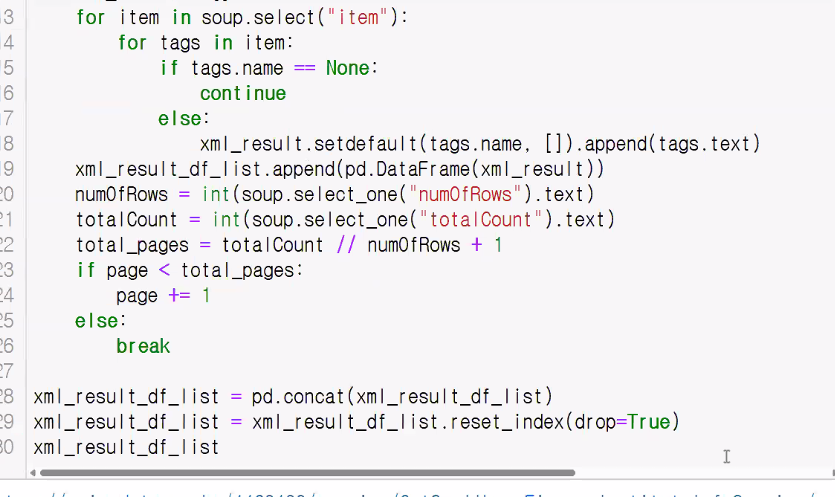

In [28]:
xml_result_df_list = []
page = 1
while True:
    url = "https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo"
    servicekey = "cNx+1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO/U+UhQqKv2E4WScQrT/mI1hrZR4ayBRqtIaKHC3BywjHiX3w=="
    payload = dict(servicekey = servicekey, numOfRows = 1000, pageNo = page, resultType = "xml")
    r = requests.get(url, params=payload)
    print(r.url)
    print(r.status_code)
    response = r.content # 파싱할 때는 text 보다 좋다
    soup = bs(response, "xml")
    xml_result = {}
    for item in soup.select('item'):
        for tags in item:
            if tags.name == None:
                continue
            else:
                xml_result.setdefault(tags.name, []).append(tags.text)

    xml_result_df = pd.DataFrame(xml_result)
    xml_result_df_list.append(xml_result_df)
    numOfRows = int(soup.select_one("numOfRows").text)
    totalCount = int(soup.select_one("totalCount").text)
    total_pages = totalCount // numOfRows + 1
    if page < total_pages:
        page += 1
    else:
        break
        
xml_result_df_list = pd.concat(xml_result_df_list)
xml_result_df_list = xml_result_df_list.reset_index(drop=True)
xml_result_df_list

https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&numOfRows=1000&pageNo=1&resultType=xml
200
https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&numOfRows=1000&pageNo=2&resultType=xml
200
https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&numOfRows=1000&pageNo=3&resultType=xml
200
https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&numOfRows=1

,basYm,snq,finPrdNm,lnLmt,irtCtg,irt,maxTotLnTrm,maxDfrmTrm,maxRdptTrm,rdptMthd,...,prdExisYn,cv19Rfrc,prdCtg,prdNm,cv19SuprCtg,cv19SuprCtn,cv19SuprTgtDtlCtn,mgmDln,prdCtg2,fileWrtDt
0,202503,1,새희망홀씨Ⅱ,3500만원,변동금리,은행별 상이,은행별 상이,-,-,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
1,202503,2,징검다리론,3000만원,변동금리,은행별 상이,5년,1년,4년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,기관 문의,-,202504010700
2,202503,3,"우리지역 氣-Up 서포트론(영세 소기업,소상공인)","5,00010,000 (코로나 19 피해 소기업, 소상공인)",변동금리,6.27~8.97%,5년,1년,4년,원금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
3,202503,4,경상남도 청년 전세자금(경상남도 협약 상품)(경상남도 청년주택 임차보증금 이자지원사업),9000만원,변동금리,은행별 상이,임대차계약기간 이내 최대 2년,0년,0년,일시상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
4,202503,5,i-ONE근로자생활안정자금대출,1000만원,고정금리,1.5 / 2.6 / 1.0 / 3.0,"근로자생활안정자금, 임금체불생계비, 체불근로자생계비 : 2년, 4년, 5년, 6년,...",6년,5년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4736,202110,425,"온(溫, ON)택트 특례보증",2850만원,변동금리,대출실행 은행에 문의,5년,1년,4년,원금균등분할상환,...,Y,,1,대출상품,,,,,,202502010700
4737,202110,426,위기업종 지원 협약보증,5000만원,-,-,"1, 5년",1년,4년,원금균등분할상환,...,Y,,1,대출상품,,,,,,202502010700
4738,202110,427,익산시 소상공인 특례보증(2023 하나은행 출연),5000만원,고정금리,약 1.6%,5년,1년,4년,원금균등분할상환,...,Y,,1,대출상품,,,,,,202502010700
4739,202110,428,중소벤처기업부 소상공인자금,7000만원,자금별 별도금리 적용,-,5년,2년,3년,분할상환,...,Y,,1,대출상품,,,,,,202502010700


In [ ]:
numOfRows = int(soup.select_one("numOfRows").text)
totalCount = int(soup.select_one("totalCount").text)
total_pages = totalCount // numOfRows + 1

setdefault를 이용해 xml의 tag명의 유일값 추출하기

In [9]:
tag_names = {}
for tags in soup.select("*"):
    tag_names.setdefault(tags.name, "")
for tag_name in tag_names.keys():
    print(tag_name)

response
header
resultCode
resultMsg
body
numOfRows
pageNo
totalCount
items
item
basYm
snq
finPrdNm
lnLmt
irtCtg
irt
maxTotLnTrm
maxDfrmTrm
maxRdptTrm
rdptMthd
usge
trgt
instCtg
ofrInstNm
rsdAreaPamtEqltIstm
suprTgtDtlCond
age
incm
rsdArea
crdtSc
anin
housHoldCnt
housAr
lnTgtHous
rfrcCnpl
grnInst
jnMthd
rpymdCfe
lnIcdcst
ovItrYr
prftAddIrtCond
etcRefSbjc
hdlInst
cnpl
rltSite
tgtFltr
hdlInstDtlVw
prdExisYn
cv19Rfrc
prdCtg
prdNm
cv19SuprCtg
cv19SuprCtn
cv19SuprTgtDtlCtn
mgmDln
prdCtg2
fileWrtDt


In [19]:
xml_result = {}
for item in soup.select('item'):
    for tags in item:
        if tags.name == None:
            continue
        else:
            xml_result.setdefault(tags.name, []).append(tags.text)

xml_result_df = pd.DataFrame(xml_result)
xml_result_df

,basYm,snq,finPrdNm,lnLmt,irtCtg,irt,maxTotLnTrm,maxDfrmTrm,maxRdptTrm,rdptMthd,...,prdExisYn,cv19Rfrc,prdCtg,prdNm,cv19SuprCtg,cv19SuprCtn,cv19SuprTgtDtlCtn,mgmDln,prdCtg2,fileWrtDt
0,202111,465,전라북도 더불어행복론,1500만원,고정금리,2.0~4.0%,5년,0년,5년,원리금균등분할상환,...,Y,,1,대출상품,,,,상시,정책자금,202111151046
1,202111,466,소상공인 고용연계 융자지원,1000만원,고정금리,2%,5년,2년,3년,거치기간 후 상환기간 동안 매월 원금균등분할상환,...,Y,,1,대출상품,,,,2021.4.12~자금 소진 시까지,정책자금,202111151046
2,202111,467,소상공인 사업장 구입자금,100000만원,은행별 상이,은행금리-1.0,15년 이내,1~5,은행별 상이 (8~10년),"일시상환방식, 분할상환방식",...,Y,,1,대출상품,,,,2021.4.1~자금 소진 시까지,정책자금,202111151046
3,202111,468,취약계층 소상공인 희망드림 특례보증,2000만원,은행별 상이,연 1.5% 지원 (인천시),5년,1년,4년,원금분할상환,...,Y,,1,대출상품,,,,2021.3.22∼자금 소진 시까지,정책자금,202111151046
4,202111,469,코로나19 위기극복 소상공인 특례보증,2000만원,고정금리,2.7%,"2, 5년","0, 2년",0년,만기일시상환,...,Y,,1,대출상품,,,,한도 소진 시까지,정책자금,202111151046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
736,202110,425,"온(溫, ON)택트 특례보증",2850만원,변동금리,대출실행 은행에 문의,5년,1년,4년,원금균등분할상환,...,Y,,1,대출상품,,,,,,202502010700
737,202110,426,위기업종 지원 협약보증,5000만원,-,-,"1, 5년",1년,4년,원금균등분할상환,...,Y,,1,대출상품,,,,,,202502010700
738,202110,427,익산시 소상공인 특례보증(2023 하나은행 출연),5000만원,고정금리,약 1.6%,5년,1년,4년,원금균등분할상환,...,Y,,1,대출상품,,,,,,202502010700
739,202110,428,중소벤처기업부 소상공인자금,7000만원,자금별 별도금리 적용,-,5년,2년,3년,분할상환,...,Y,,1,대출상품,,,,,,202502010700


# key_list를 만들고 select로 직접 추출하기 

In [57]:
df_list = []
page = 1
while True:
    url = "https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo"
    servicekey = "cNx+1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO/U+UhQqKv2E4WScQrT/mI1hrZR4ayBRqtIaKHC3BywjHiX3w=="
    payload = dict(servicekey = servicekey, numOfRows = 1000, pageNo = page, resultType = "xml")
    r = requests.get(url, params=payload)
    print(r.url)
    print(r.status_code)
    numOfRows = int(soup.select_one("numOfRows").text)
    totalCount = int(soup.select_one("totalCount").text)
    total_pages =  totalCount / numOfRows
    response = r.content # 파싱할 때는 text 보다 좋다
    soup = bs(response, "xml")
    key_list = {}
    for item in soup.select("*"):
        key_list.setdefault(item.name, "")
    keys = list(key_list.keys())
    result = {}
    for key in keys[10:]:
        for item in soup.select(key):
            result.setdefault(item.name, []).append(item.text)
    df_list.append(pd.DataFrame(result)) 
    if page < total_pages:
        page += 1
    else:
        print("데이터 수집완료")
        break
result_df = pd.concat(df_list)
result_df = result_df.reset_index(drop=True)
result_df

https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&numOfRows=1000&pageNo=1&resultType=xml
200
https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&numOfRows=1000&pageNo=2&resultType=xml
200
https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&numOfRows=1000&pageNo=3&resultType=xml
200
https://apis.data.go.kr/1160100/service/GetSmallLoanFinanceInstituteInfoService/getOrdinaryFinanceInfo?servicekey=cNx%2B1qrXIfATijXRStPn7A5nRbqTbMX7a6hHqO%2FU%2BUhQqKv2E4WScQrT%2FmI1hrZR4ayBRqtIaKHC3BywjHiX3w%3D%3D&numOfRows=1

,basYm,snq,finPrdNm,lnLmt,irtCtg,irt,maxTotLnTrm,maxDfrmTrm,maxRdptTrm,rdptMthd,...,prdExisYn,cv19Rfrc,prdCtg,prdNm,cv19SuprCtg,cv19SuprCtn,cv19SuprTgtDtlCtn,mgmDln,prdCtg2,fileWrtDt
0,202503,1,새희망홀씨Ⅱ,3500만원,변동금리,은행별 상이,은행별 상이,-,-,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
1,202503,2,징검다리론,3000만원,변동금리,은행별 상이,5년,1년,4년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,기관 문의,-,202504010700
2,202503,3,"우리지역 氣-Up 서포트론(영세 소기업,소상공인)","5,00010,000 (코로나 19 피해 소기업, 소상공인)",변동금리,6.27~8.97%,5년,1년,4년,원금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
3,202503,4,경상남도 청년 전세자금(경상남도 협약 상품)(경상남도 청년주택 임차보증금 이자지원사업),9000만원,변동금리,은행별 상이,임대차계약기간 이내 최대 2년,0년,0년,일시상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
4,202503,5,i-ONE근로자생활안정자금대출,1000만원,고정금리,1.5 / 2.6 / 1.0 / 3.0,"근로자생활안정자금, 임금체불생계비, 체불근로자생계비 : 2년, 4년, 5년, 6년,...",6년,5년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4736,202110,425,"온(溫, ON)택트 특례보증",2850만원,변동금리,대출실행 은행에 문의,5년,1년,4년,원금균등분할상환,...,Y,,1,대출상품,,,,,,202502010700
4737,202110,426,위기업종 지원 협약보증,5000만원,-,-,"1, 5년",1년,4년,원금균등분할상환,...,Y,,1,대출상품,,,,,,202502010700
4738,202110,427,익산시 소상공인 특례보증(2023 하나은행 출연),5000만원,고정금리,약 1.6%,5년,1년,4년,원금균등분할상환,...,Y,,1,대출상품,,,,,,202502010700
4739,202110,428,중소벤처기업부 소상공인자금,7000만원,자금별 별도금리 적용,-,5년,2년,3년,분할상환,...,Y,,1,대출상품,,,,,,202502010700


In [56]:
result_df = pd.concat(df_list)
result_df = result_df.reset_index(drop=True)
result_df

,basYm,snq,finPrdNm,lnLmt,irtCtg,irt,maxTotLnTrm,maxDfrmTrm,maxRdptTrm,rdptMthd,...,prdExisYn,cv19Rfrc,prdCtg,prdNm,cv19SuprCtg,cv19SuprCtn,cv19SuprTgtDtlCtn,mgmDln,prdCtg2,fileWrtDt
0,202503,1,새희망홀씨Ⅱ,3500만원,변동금리,은행별 상이,은행별 상이,-,-,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
1,202503,2,징검다리론,3000만원,변동금리,은행별 상이,5년,1년,4년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,기관 문의,-,202504010700
2,202503,3,"우리지역 氣-Up 서포트론(영세 소기업,소상공인)","5,00010,000 (코로나 19 피해 소기업, 소상공인)",변동금리,6.27~8.97%,5년,1년,4년,원금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
3,202503,4,경상남도 청년 전세자금(경상남도 협약 상품)(경상남도 청년주택 임차보증금 이자지원사업),9000만원,변동금리,은행별 상이,임대차계약기간 이내 최대 2년,0년,0년,일시상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
4,202503,5,i-ONE근로자생활안정자금대출,1000만원,고정금리,1.5 / 2.6 / 1.0 / 3.0,"근로자생활안정자금, 임금체불생계비, 체불근로자생계비 : 2년, 4년, 5년, 6년,...",6년,5년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4736,202110,425,"온(溫, ON)택트 특례보증",2850만원,변동금리,대출실행 은행에 문의,5년,1년,4년,원금균등분할상환,...,Y,,1,대출상품,,,,,,202502010700
4737,202110,426,위기업종 지원 협약보증,5000만원,-,-,"1, 5년",1년,4년,원금균등분할상환,...,Y,,1,대출상품,,,,,,202502010700
4738,202110,427,익산시 소상공인 특례보증(2023 하나은행 출연),5000만원,고정금리,약 1.6%,5년,1년,4년,원금균등분할상환,...,Y,,1,대출상품,,,,,,202502010700
4739,202110,428,중소벤처기업부 소상공인자금,7000만원,자금별 별도금리 적용,-,5년,2년,3년,분할상환,...,Y,,1,대출상품,,,,,,202502010700


In [51]:
numOfRows = int(soup.select_one("numOfRows").text)
totalCount = int(soup.select_one("totalCount").text)
total_pages =  totalCount / numOfRows

In [48]:
totalCount

4741

In [46]:
keys

['response',
 'header',
 'resultCode',
 'resultMsg',
 'body',
 'numOfRows',
 'pageNo',
 'totalCount',
 'items',
 'item',
 'basYm',
 'snq',
 'finPrdNm',
 'lnLmt',
 'irtCtg',
 'irt',
 'maxTotLnTrm',
 'maxDfrmTrm',
 'maxRdptTrm',
 'rdptMthd',
 'usge',
 'trgt',
 'instCtg',
 'ofrInstNm',
 'rsdAreaPamtEqltIstm',
 'suprTgtDtlCond',
 'age',
 'incm',
 'rsdArea',
 'crdtSc',
 'anin',
 'housHoldCnt',
 'housAr',
 'lnTgtHous',
 'rfrcCnpl',
 'grnInst',
 'jnMthd',
 'rpymdCfe',
 'lnIcdcst',
 'ovItrYr',
 'prftAddIrtCond',
 'etcRefSbjc',
 'hdlInst',
 'cnpl',
 'rltSite',
 'tgtFltr',
 'hdlInstDtlVw',
 'prdExisYn',
 'cv19Rfrc',
 'prdCtg',
 'prdNm',
 'cv19SuprCtg',
 'cv19SuprCtn',
 'cv19SuprTgtDtlCtn',
 'mgmDln',
 'prdCtg2',
 'fileWrtDt']

In [34]:
key_list = {}
for item in soup.select("*"):
    key_list.setdefault(item.name, "")
key_list = list(key_list.keys())
key_list

['response',
 'header',
 'resultCode',
 'resultMsg',
 'body',
 'numOfRows',
 'pageNo',
 'totalCount',
 'items',
 'item',
 'basYm',
 'snq',
 'finPrdNm',
 'lnLmt',
 'irtCtg',
 'irt',
 'maxTotLnTrm',
 'maxDfrmTrm',
 'maxRdptTrm',
 'rdptMthd',
 'usge',
 'trgt',
 'instCtg',
 'ofrInstNm',
 'rsdAreaPamtEqltIstm',
 'suprTgtDtlCond',
 'age',
 'incm',
 'rsdArea',
 'crdtSc',
 'anin',
 'housHoldCnt',
 'housAr',
 'lnTgtHous',
 'rfrcCnpl',
 'grnInst',
 'jnMthd',
 'rpymdCfe',
 'lnIcdcst',
 'ovItrYr',
 'prftAddIrtCond',
 'etcRefSbjc',
 'hdlInst',
 'cnpl',
 'rltSite',
 'tgtFltr',
 'hdlInstDtlVw',
 'prdExisYn',
 'cv19Rfrc',
 'prdCtg',
 'prdNm',
 'cv19SuprCtg',
 'cv19SuprCtn',
 'cv19SuprTgtDtlCtn',
 'mgmDln',
 'prdCtg2',
 'fileWrtDt']

In [37]:
keys = key_list[10:]

In [40]:
soup.select("basYm")
soup.select("snq")


[<basYm>202503</basYm>,
 <basYm>202503</basYm>,
 <basYm>202503</basYm>,
 <basYm>202503</basYm>,
 <basYm>202503</basYm>,
 <basYm>202503</basYm>,
 <basYm>202503</basYm>,
 <basYm>202503</basYm>,
 <basYm>202503</basYm>,
 <basYm>202503</basYm>]

In [42]:
result = {}
for key in keys:
    for item in soup.select(key):
        result.setdefault(item.name, []).append(item.text)
df = pd.DataFrame(result)
df

,basYm,snq,finPrdNm,lnLmt,irtCtg,irt,maxTotLnTrm,maxDfrmTrm,maxRdptTrm,rdptMthd,...,prdExisYn,cv19Rfrc,prdCtg,prdNm,cv19SuprCtg,cv19SuprCtn,cv19SuprTgtDtlCtn,mgmDln,prdCtg2,fileWrtDt
0,202503,1,새희망홀씨Ⅱ,3500만원,변동금리,은행별 상이,은행별 상이,-,-,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
1,202503,2,징검다리론,3000만원,변동금리,은행별 상이,5년,1년,4년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,기관 문의,-,202504010700
2,202503,3,"우리지역 氣-Up 서포트론(영세 소기업,소상공인)","5,00010,000 (코로나 19 피해 소기업, 소상공인)",변동금리,6.27~8.97%,5년,1년,4년,원금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
3,202503,4,경상남도 청년 전세자금(경상남도 협약 상품)(경상남도 청년주택 임차보증금 이자지원사업),9000만원,변동금리,은행별 상이,임대차계약기간 이내 최대 2년,0년,0년,일시상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
4,202503,5,i-ONE근로자생활안정자금대출,1000만원,고정금리,1.5 / 2.6 / 1.0 / 3.0,"근로자생활안정자금, 임금체불생계비, 체불근로자생계비 : 2년, 4년, 5년, 6년,...",6년,5년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
5,202503,6,IBK청년전·월세대출 (전세),20000만원,"고정금리, 변동금리",3.8~4.3%,3년,3년,0년,만기일시상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
6,202503,7,IBK청년전·월세대출 (월세),1200만원,변동금리,4.34%,"11, 13년",8년,"3, 5년",원금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
7,202503,8,사잇돌Ⅱ대출_표준,3000만원,변동금리,~19.99%,"5(최대 60개월, 보증기간 이내)",0년,5년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
8,202503,9,사잇돌Ⅱ대출_대환형,2000만원,변동금리,~19.99%,"5(최대 60개월, 보증기간 이내)",0년,5년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,상시,-,202504010700
9,202503,10,사잇돌Ⅱ대출_채무조정졸업자,1000만원,변동금리,~19.99%,"5(최대 60개월, 보증기간 이내)",0년,5년,원(리)금균등분할상환,...,Y,-,1,대출상품,-,-,-,기관 문의,-,202504010700
